# Relative & absolute accuracy — M3C2 stack

Figures produced from the M3C2 signal:

- **Orthomosaic + coverage + NMAD maps** (one row) — the UAV + TLC reference orthomosaic (clipped to the coverage footprint), the per-pixel number of dates with a valid M3C2, and the per-pixel temporal NMAD (`n ≥ MIN_OBS`). Over the whole footprint the NMAD also captures *real* glacier change, so it reads high on the moving tongue and low on stable ground.
- **Relative accuracy** — the precision (repeatability) of the acquisitions: per-pixel temporal SD and NMAD of the stable-terrain stack.
- **Absolute accuracy** — each acquisition's stable-terrain offset from the reference, over time.

Both accuracy figures reduce **one gridded matrix**. The per-date stable-terrain M3C2 distances (`coreg/*_m3c2_distances.npz`, computed in point space on the fixed reference corepoints) are binned onto a **1 m grid** — the median of the corepoints in each cell, per date — giving a `(dates × stable pixels)` matrix. The absolute accuracy reduces it *across cells* (one box per acquisition); the relative accuracy reduces it *along time* (SD/NMAD per cell). Same unit, directly comparable, and the same 1 m unit as the maps above.

**Why grid rather than work in point space?** Corepoint density varies from 1 to several hundred points per square metre, so averaging over corepoints would weight the result by point density instead of by area — flattering it, since dense patches are the well-observed, low-noise ones. On the grid every square metre of stable ground counts once, and the numbers describe the precision of the gridded M3C2 product we actually distribute.

**Why the M3C2 spread is a valid precision estimate:** every acquisition is differenced against the *same* reference cloud, so the reference elevation is a constant in time — it shifts the temporal mean but cancels out of the temporal SD/NMAD. The reference's own error therefore lands in the (discarded) per-pixel bias, not in the precision.

Functions live in `cntp.postprocessing` (loaders + orchestrators) and `cntp.plot` (drawing); `tools` re-exports them.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import sys
from pathlib import Path

# Make examples/ (site_config) importable, regardless of the kernel's cwd.
_here = Path.cwd()
_repo = next((p for p in [_here, *_here.parents]
              if (p / "examples" / "site_config.py").exists()), None)
if _repo is None:
    raise RuntimeError("could not locate repo root (examples/site_config.py) from "
                       f"{_here}; open this notebook inside the CNTP_hackathon repo.")
if str(_repo / "examples") not in sys.path:
    sys.path.insert(0, str(_repo / "examples"))

import site_config as site
from cntp.postprocessing import pixel_relative_accuracy, absolute_accuracy_boxplots

print("output_dir:", site.output_dir)

output_dir: /mnt/e/umayr/Changri/Changri_North


## Config

`MIN_OBS` gates **both** the whole-glacier NMAD map and the stable boxplot (one threshold). `BIN_DAYS` sets the absolute-accuracy cadence (14 = biweekly).

`MAX_NMAD` / `MAX_NMAD_FROM` drop poorly co-registered acquisitions, using the per-date NMAD the pipeline already reported. The same retained-day set feeds the coverage map, the NMAD map, the relative accuracy and the absolute accuracy, so `MIN_OBS` counts only days that were actually used.

In [2]:
SITE_LABEL = "Changri North"
MIN_OBS    = 10   # min valid dates per pixel (maps + relative accuracy)
BIN_DAYS   = 14   # absolute-accuracy cadence (14 = biweekly)
SAVE_PDF   = True # write a vector PDF alongside each PNG

# Coregistration-quality gate: drop acquisitions whose post-coreg stable NMAD
# is >= MAX_NMAD. MAX_NMAD_FROM restricts the gate to that date onward, leaving
# an earlier, unaffected period reported as-is.
#   Changri West : None / None            -> no gate on the maps
#   Changri North: 0.5 / "2024-07-15"     -> C8+C9 lost 15 Jul, C7 mid-Oct;
#                                            monsoon cloud degrades the coreg
MAX_NMAD      = 0.5
MAX_NMAD_FROM = "2024-07-15"

# Every figure is written here and also shown inline (show=True).
PLOT_DIR = Path(site.output_dir) / "output" / "postprocessing" / "precision"
print("figures ->", PLOT_DIR)

figures -> /mnt/e/umayr/Changri/Changri_North/output/postprocessing/precision


## Orthomosaic + coverage + NMAD maps, and the relative-accuracy boxplot

Figures are saved to `PLOT_DIR` (PNG + PDF) **and** rendered inline (`show=True`). The three maps share one grid, one viewing window and the same footprint: the orthomosaic is resampled onto the M3C2 grid and made transparent outside the coverage, so every panel shows the same glacier shape.

Writes `pixel_maps.png` and `stable_relative_accuracy.png`.

  Loaded 317 M3C2_raster rasters from cache ((317, 1214, 1453), 2.24 GB) -> /home/vaw_a/.cache/cntp_signalstack/Changri_North__M3C2_raster__all__all.cube.npy
  NMAD gate (>= 0.5 m, from 2024-07-15): kept 253/317 acquisitions for the maps
  Saved: /mnt/e/umayr/Changri/Changri_North/output/postprocessing/precision/pixel_maps.png


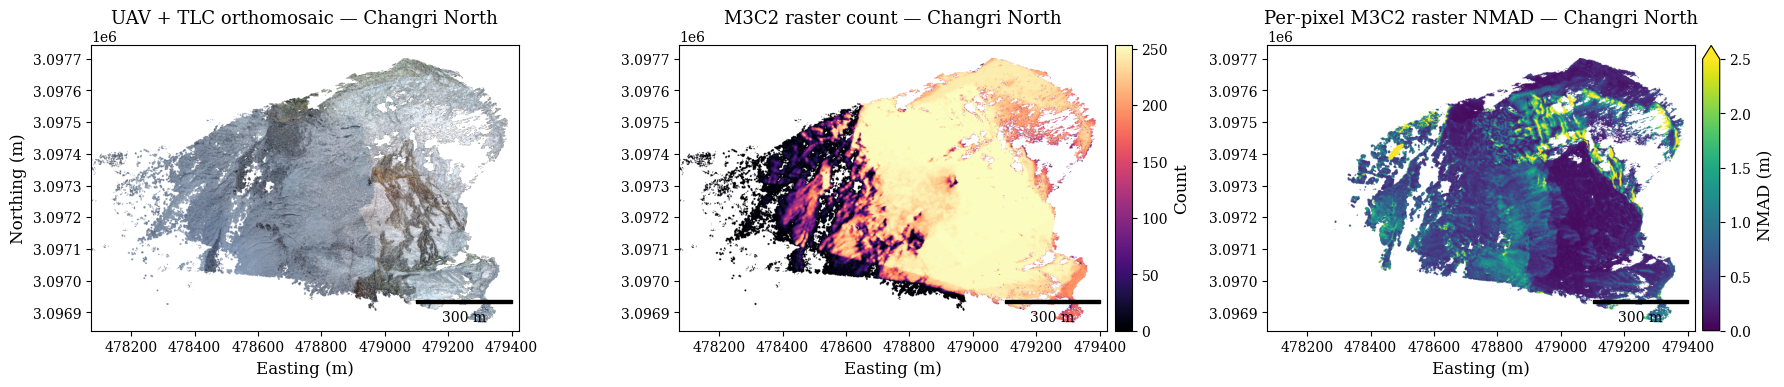

  Loaded 317 stable-M3C2 'after' distance arrays -> matrix (317, 2821575) (2023-11-27 ... 2024-11-17)
  Gridded stable distances to 1 m -> 317 dates x 72,636 cells (72,636 m^2 stable)
  NMAD gate (>= 0.5 m, from 2024-07-15): kept 253/317 acquisitions
  Saved: /mnt/e/umayr/Changri/Changri_North/output/postprocessing/precision/stable_relative_accuracy.png


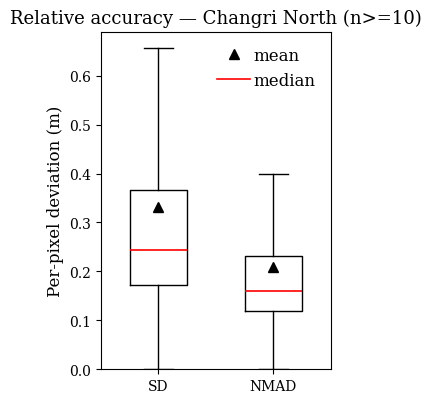


  [Changri North] stable-terrain relative accuracy (49,301 stable 1 m pixels, n>=10, 'after'):
    NMAD — mean 0.209 m  median 0.160 m
    SD   — mean 0.331 m  median 0.243 m


In [3]:
res = pixel_relative_accuracy(site.output_dir, min_obs=MIN_OBS,
                              site_label=SITE_LABEL, plot_dir=PLOT_DIR,
                              max_nmad=MAX_NMAD, max_nmad_from=MAX_NMAD_FROM,
                              show=True, save_pdf=SAVE_PDF)

## Relative accuracy (the reported numbers)

Mean / median of the per-pixel temporal SD and NMAD over stable 1 m pixels (cells with `n ≥ MIN_OBS` observations). These agree with the boxplot above. Quote the **NMAD** — the daily M3C2 has heavy-tailed blunder dates that inflate SD but barely move the median absolute deviation.

In [4]:
import pandas as pd
s = res["stable_stats"]
pd.DataFrame({
    "mean (m)":   [s["sd"]["mean"],   s["nmad"]["mean"]],
    "median (m)": [s["sd"]["median"], s["nmad"]["median"]],
    "n pixels":   [s["sd"]["n"],      s["nmad"]["n"]],
}, index=["SD", "NMAD"]).round(3)

,mean (m),median (m),n pixels
SD,0.331,0.243,49301
NMAD,0.209,0.160,49301


## Absolute accuracy over time

Each box is one **acquisition's** stable-terrain M3C2 distances against the reference cloud (post-coreg `after` residuals), on the same 1 m grid — so one sample = one square metre of stable ground. A box centred on 0 means coregistration left no bias; the IQR/whiskers (1.5×IQR, fliers hidden) are that acquisition's precision.

Boxes are drawn on a regular `BIN_DAYS`-day cadence: each slot takes the acquisition **nearest** to that slot's date, in either direction, so gaps in the record are filled by the closest one. If two are equidistant, the one with the **lower post-coreg NMAD** wins. Acquisitions whose post-coreg stable NMAD is ≥ 0.5 m (`max_nmad`) are excluded first — failed coregistrations whose metre-scale bias and spread would otherwise dominate the y-axis.

Box colour = that acquisition's stable surface area (m² = grid cells observed). The returned records carry `date` (the slot), `source_date` (the acquisition actually used) and `offset_days`, so you can see which slots borrowed a neighbour.

  Loaded 317 stable-M3C2 'after' distance arrays -> matrix (317, 2821575) (2023-11-27 ... 2024-11-17)
  Gridded stable distances to 1 m -> 317 dates x 72,636 cells (72,636 m^2 stable)
  Excluded 64 acquisition(s): post-coreg NMAD >= 0.5 m (from 2024-07-15)
  Saved: /mnt/e/umayr/Changri/Changri_North/output/postprocessing/precision/stable_absolute_accuracy.png


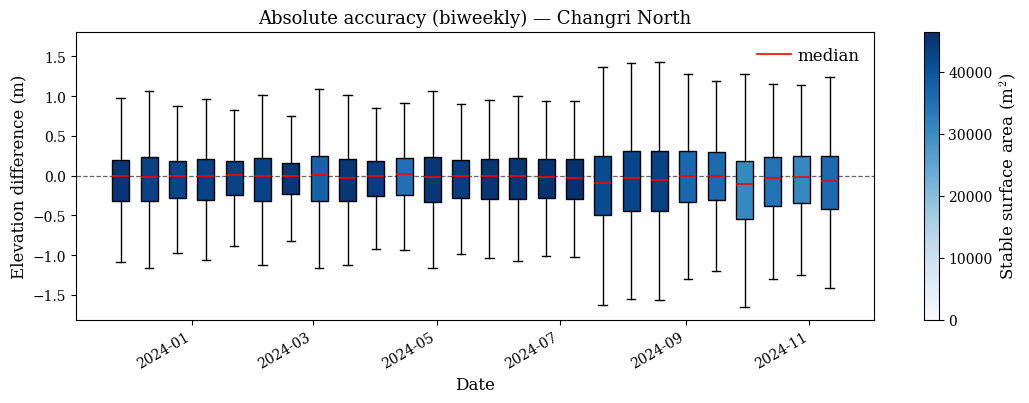

26 boxes plotted


In [5]:
recs = absolute_accuracy_boxplots(site.output_dir, bin_days=BIN_DAYS,
                                  site_label=SITE_LABEL, plot_dir=PLOT_DIR,
                                  max_nmad=MAX_NMAD, max_nmad_from=MAX_NMAD_FROM,
                                  show=True, save_pdf=SAVE_PDF)
print(f"{len(recs)} boxes plotted")